## Self Organizing Maps
**Yasir Ahmad**  
22MIA1064
Clustering 2
1. Implement any two different distance metric for Self Organizing Maps

a) Euclidean Distance (KSOM)

b) Canonical correlation analysis (CCA- SOM)

c) Adaptive Subspace SOM (ASSOM)



2. Implement DBSCAN by applying different distance metric

In [1]:
!pip install minisom simpsom

  Preparing metadata (setup.py) ... - done
  Created wheel for minisom: filename=MiniSom-2.3.3-py3-none-any.whl size=11705 sha256=1d352300f450ca1d96d7fd04e441c569eb5598fe249027940387b0ccae4f8412
  Stored in directory: /root/.cache/pip/wheels/96/98/a5/52dee3e8ed1dbfc4d77e4da41b6d89dd7ab9ead1b921e766f8
Successfully built minisom


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from pylab import bone, pcolor, colorbar, plot, show

import simpsom as sps
from minisom import MiniSom

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
paths = []
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        paths.append(os.path.join(dirname, filename))
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/iris/Iris.csv
/kaggle/input/iris/database.sqlite
/kaggle/input/credit-card-applications/Credit_Card_Applications.csv


In [3]:
df=pd.read_csv(paths[0])
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
df.rename(columns={'Species':'Class'},inplace=True)

In [5]:
df['Class']

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: Class, Length: 150, dtype: object

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit_transform(df['Class'])

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [7]:
df["Class"]=le.fit_transform(df['Class'])

In [8]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Class
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


In [9]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Class
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667,1.000000
std,43.445368,0.828066,0.433594,1.764420,0.763161,0.819232
min,1.000000,4.300000,2.000000,1.000000,0.100000,0.000000
25%,38.250000,5.100000,2.800000,1.600000,0.300000,0.000000
50%,75.500000,5.800000,3.000000,4.350000,1.300000,1.000000
75%,112.750000,6.400000,3.300000,5.100000,1.800000,2.000000
max,150.000000,7.900000,4.400000,6.900000,2.500000,2.000000


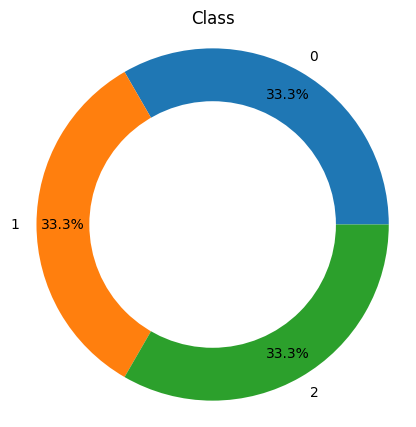

In [10]:
from matplotlib import pyplot as plt
fig1, ax1 = plt.subplots(figsize=(5,5))

index = df['Class'].value_counts().index
size = df['Class'].value_counts().values

plt.pie(size, labels=index, 
        autopct='%1.1f%%', pctdistance=0.85,)

# Inner circle
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

ax1.axis('equal')  
plt.title("Class")
plt.show()

In [11]:
y = df['Class']
df = df.drop("Class",axis=1)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

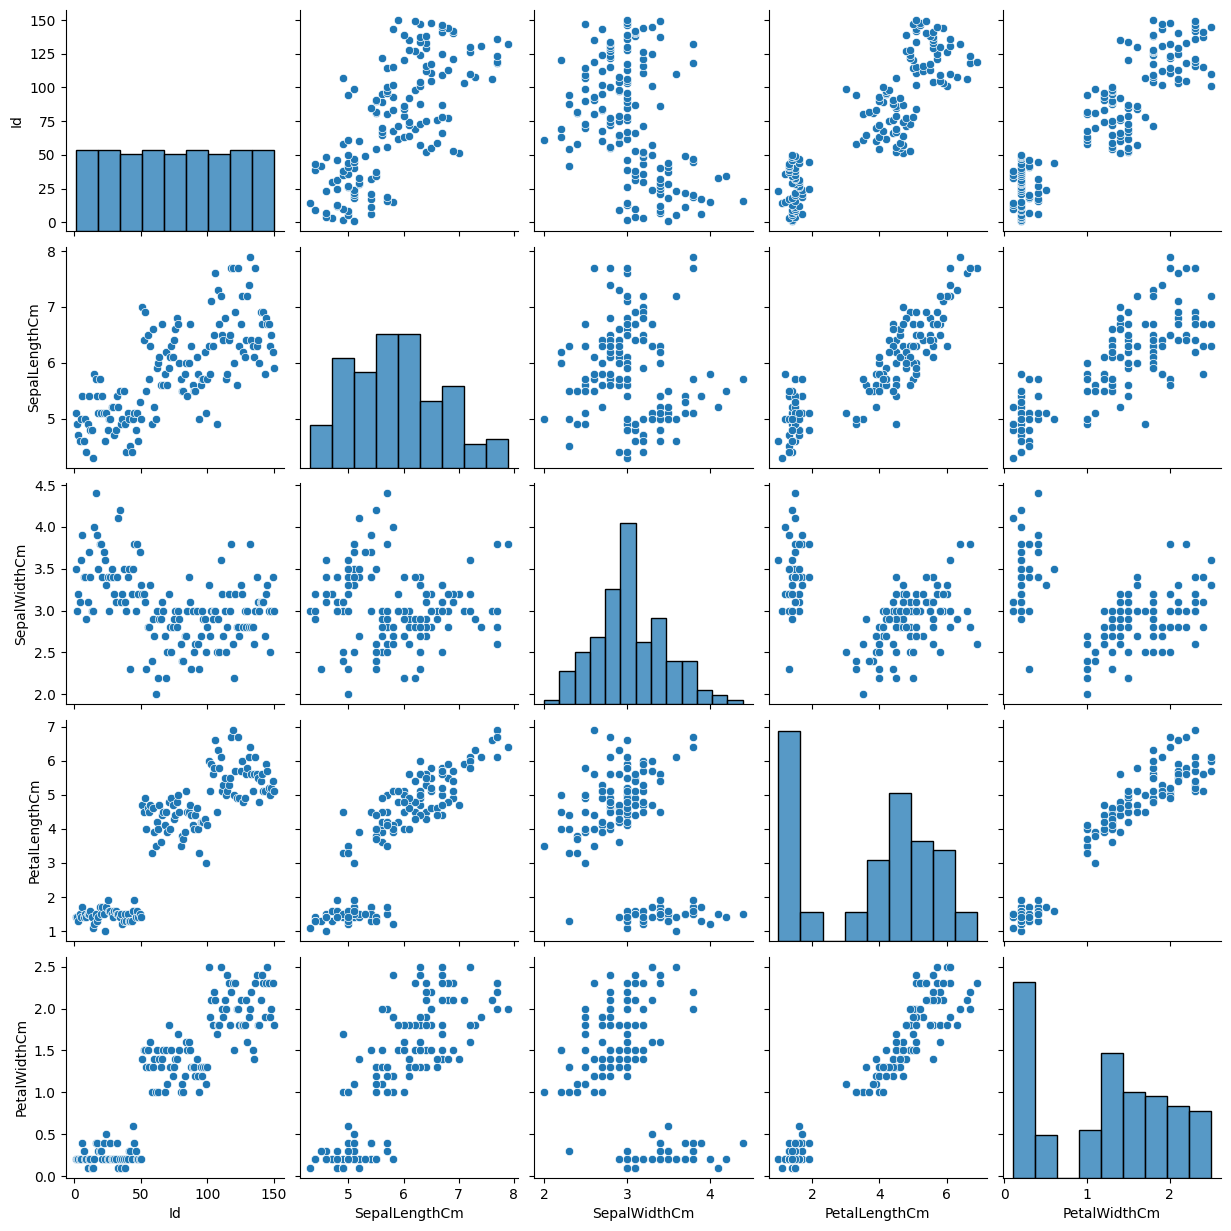

In [12]:
import seaborn as sns
sns.pairplot(df)

In [13]:
scaler = MinMaxScaler(feature_range = (0,1))
df1 = scaler.fit_transform(df)
df1

array([[0.        , 0.22222222, 0.625     , 0.06779661, 0.04166667],
       [0.00671141, 0.16666667, 0.41666667, 0.06779661, 0.04166667],
       [0.01342282, 0.11111111, 0.5       , 0.05084746, 0.04166667],
       [0.02013423, 0.08333333, 0.45833333, 0.08474576, 0.04166667],
       [0.02684564, 0.19444444, 0.66666667, 0.06779661, 0.04166667],
       [0.03355705, 0.30555556, 0.79166667, 0.11864407, 0.125     ],
       [0.04026846, 0.08333333, 0.58333333, 0.06779661, 0.08333333],
       [0.04697987, 0.19444444, 0.58333333, 0.08474576, 0.04166667],
       [0.05369128, 0.02777778, 0.375     , 0.06779661, 0.04166667],
       [0.06040268, 0.16666667, 0.45833333, 0.08474576, 0.        ],
       [0.06711409, 0.30555556, 0.70833333, 0.08474576, 0.04166667],
       [0.0738255 , 0.13888889, 0.58333333, 0.10169492, 0.04166667],
       [0.08053691, 0.13888889, 0.41666667, 0.06779661, 0.        ],
       [0.08724832, 0.        , 0.41666667, 0.01694915, 0.        ],
       [0.09395973, 0.41666667, 0.

In [14]:
# Training the SOM

Som = MiniSom(x = 8, y = 8, input_len = 5, sigma = 1.0, learning_rate = 0.5)
Som.random_weights_init(df1)
Som.train_batch(data = df1, num_iteration = 1000,verbose=True)

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.08927950323019009


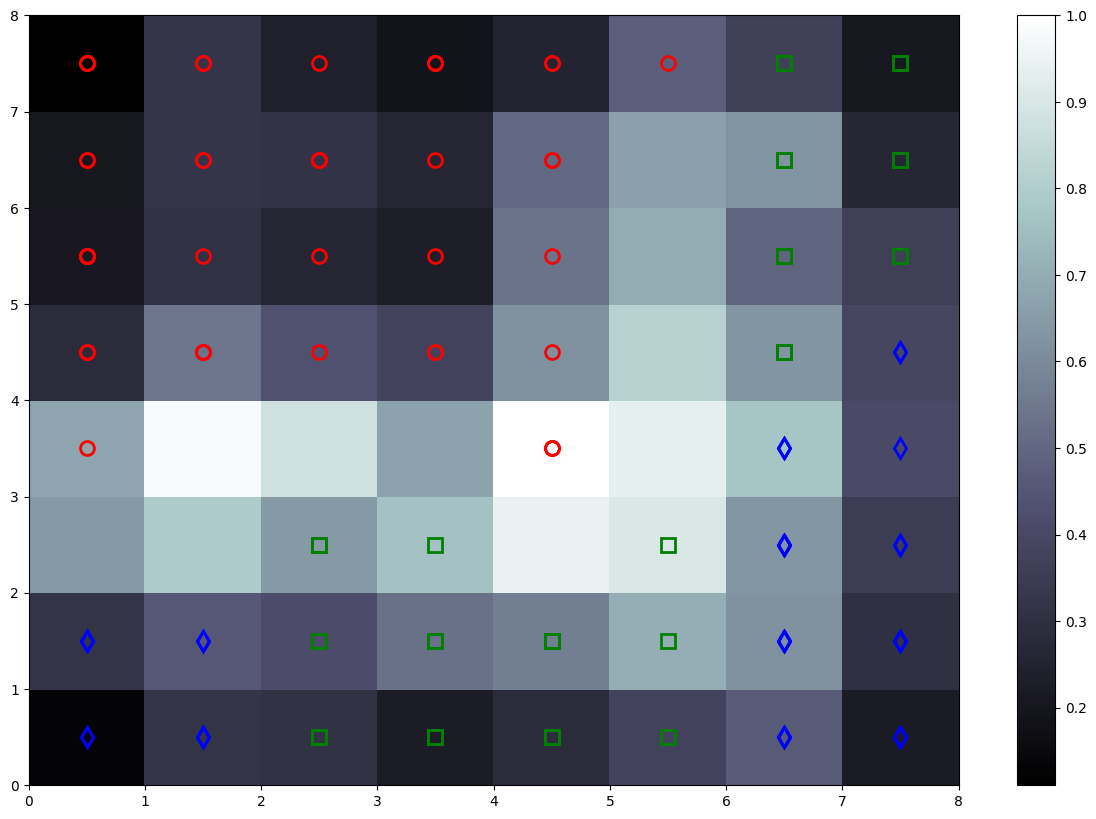

In [15]:
# Visualizing the results

plt.figure(figsize = (15,10))
bone()
pcolor(Som.distance_map().T)
colorbar()
# check if customers got approval or not, green - yes, red - no
markers = ['o','s','d'] # o/circle for red - no approval, s/square for green - approval
colors = ['r','g','b']
for i,x in enumerate(df1): # i becomes index, and x is a vector containing other attributes
    w = Som.winner(x)
    plot(w[0] + 0.5, w[1] + 0.5, markers[y[i]], markeredgecolor = colors[y[i]], markerfacecolor = 'None'
        , markersize = 10, markeredgewidth = 2)

In [16]:
le.classes_

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

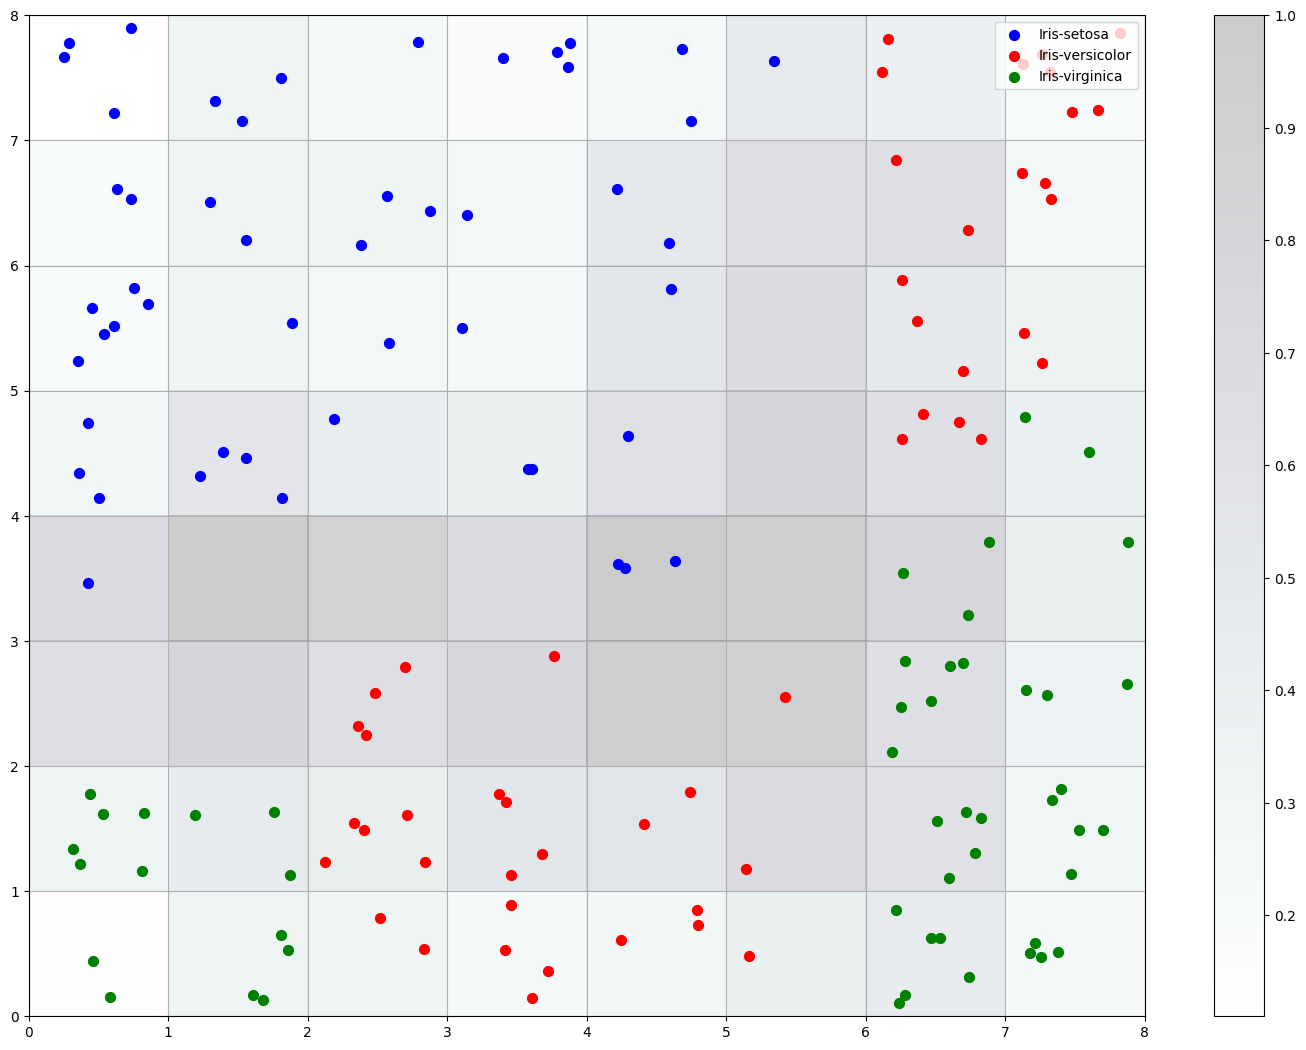

In [17]:
w_x, w_y = zip(*[Som.winner(d) for d in df1])
w_x = np.array(w_x)
w_y = np.array(w_y)
label_names = {0:'Iris-setosa', 1:'Iris-versicolor', 2:'Iris-virginica'}

plt.figure(figsize=(18, 13))
plt.pcolor(Som.distance_map().T, cmap='bone_r', alpha=.2)
plt.colorbar()

for c in np.unique(y):
    idx_target = y==c
    plt.scatter(w_x[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*.8,
                w_y[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*.8, 
                s=50, c=colors[c-1], label=label_names[c])
plt.legend(loc='upper right')
plt.grid()
plt.show()